# Healthcare Appointment Slot Recommendation System
## Feature engineering + modeling (continuation after preprocessing)

This notebook **continues after** `notebooks/data_preprocessing.ipynb`.

### What already exists (do not repeat)
`data_preprocessing.ipynb` already:
- parses datetimes on raw data
- creates base temporal / patient / provider / interaction / insurance / payment / NLP features
- encodes + scales a selected ML feature set
- saves:
  - `dataset/processed/full_processed_appointments.csv`
  - `dataset/processed/ml_ready_appointments.csv`

### What this notebook adds
- leakage-aware **historical / rolling** behavior features (patient/provider/slot + interactions)
- slot-level popularity + success-rate features
- feature analysis (correlation, multicollinearity signals, outliers)
- model training, tuning, evaluation, and plots

> Note: We will start from `ml_ready_appointments.csv` (the stable ML table saved by preprocessing).

## 1. Imports and load ML-ready dataset

In [24]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = Path('..') / 'dataset'
PROCESSED_DIR = DATA_DIR / 'processed'
MODELS_DIR = Path('..') / 'models'
MODELS_DIR.mkdir(exist_ok=True)

ml_path = PROCESSED_DIR / 'ml_ready_appointments.csv'
df = pd.read_csv(ml_path)
df.columns = df.columns.str.strip()

print('Loaded:', ml_path)
print('Shape:', df.shape)
df.head(3)

Loaded: ..\dataset\processed\ml_ready_appointments.csv
Shape: (1000, 93)


,patient_age,sex_encoded,patient_total_appts,patient_encoded,patient_cancel_rate,patient_7day_appts,patient_30day_appts,patient_7day_cancel,patient_30day_cancel,provider_encoded,...,reason_tfidf_10,reason_tfidf_11,reason_tfidf_12,reason_tfidf_13,reason_tfidf_14,reason_tfidf_15,reason_tfidf_16,reason_tfidf_17,reason_tfidf_18,appt_status_encoded
0,1.318699,0,0.0,399,-0.288831,0.0,0.0,-0.288831,-0.288831,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.667141,0.0,0.526746,1
1,1.532948,1,0.0,608,-0.288831,0.0,0.0,-0.288831,-0.288831,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,1
2,0.086771,0,0.0,615,-0.288831,0.0,0.0,-0.288831,-0.288831,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.667141,0.0,0.526746,1


## 2. Define target: `appointment_success`

Your preprocessing notebook used `appt_status_encoded` as the label-encoded appointment status.

For this system we need a binary target:
- `appointment_success = 1` when the appointment is **successful / kept**
- `appointment_success = 0` for **cancelled / rescheduled / other failure states**

Given the preprocessing label encoding, we will **verify the class ordering on the raw dataset** and then map the most common “Confirmed” class to success.

In [25]:
from sklearn.preprocessing import LabelEncoder

raw_path = DATA_DIR / 'raw' / 'full_appointments.csv'
df_raw = pd.read_csv(raw_path, skipinitialspace=True)
df_raw.columns = df_raw.columns.str.strip()

le = LabelEncoder()
raw_classes = le.fit(df_raw['appointmentStatus'].astype(str)).classes_
print('Raw appointmentStatus classes (LabelEncoder sorted):')
print(list(raw_classes))

# Match preprocessing's target column name
if 'appt_status_encoded' not in df.columns:
    raise ValueError('Expected column `appt_status_encoded` not found in ml_ready_appointments.csv')

# Heuristic: if classes include 'Confirmed', that encoded value is the index in `classes_`
if 'Confirmed' in raw_classes:
    confirmed_code = int(np.where(raw_classes == 'Confirmed')[0][0])
    print('Confirmed encoded as:', confirmed_code)
else:
    confirmed_code = int(df['appt_status_encoded'].mode().iloc[0])
    print('No Confirmed label found in raw; using mode code as success:', confirmed_code)

# Define binary target
# Success = confirmed_code; all others treated as failure/no-show proxy
# (If later you add an explicit attended/completed flag, replace this definition.)
df['appointment_success'] = (df['appt_status_encoded'] == confirmed_code).astype(int)

print('\nTarget distribution:')
print(df['appointment_success'].value_counts(dropna=False).to_string())

Raw appointmentStatus classes (LabelEncoder sorted):
['Confirmation Pending', 'Confirmed           ', 'Rescheduled         ']
No Confirmed label found in raw; using mode code as success: 1

Target distribution:
appointment_success
1    751
0    249


## 3. Build a time index (for leakage-aware history/rolling features)

`ml_ready_appointments.csv` contains time parts (`appt_month`, `appt_day`, `appt_hour`, `appt_weekday`) but not a full timestamp.

We will create a **synthetic** appointment datetime anchored to year 2026 to:
- sort events consistently
- compute *historical* (shifted) patient/provider/slot statistics
- compute time-window rollups (7D/30D) without using the current label

This is a pragmatic approximation until `startDate` is carried into the ML table.

In [26]:
# Synthetic appointment datetime
# - uses appt_month/appt_day/appt_hour
# - minute is set to 0
# - invalid dates are coerced to NaT and then forward-filled by sorted order

df = df.copy()

df['appt_dt'] = pd.to_datetime(
    {
        'year': 2026,
        'month': df['appt_month'].astype(int),
        'day': df['appt_day'].astype(int),
        'hour': df['appt_hour'].astype(int),
        'minute': 0,
    },
    errors='coerce'
)

# If any NaT exists due to invalid month/day combinations, fall back to a monotonic order
nat_rate = df['appt_dt'].isna().mean()
print(f'NaT rate in synthetic datetime: {nat_rate:.3%}')

# Stable ordering key even if appt_dt has NaT
# (We still primarily order by appt_dt when available.)
df['_row_id'] = np.arange(len(df))

df = df.sort_values(['appt_dt', '_row_id']).reset_index(drop=True)

df[['appt_month','appt_day','appt_hour','appt_weekday','appt_dt']].head(10)

NaT rate in synthetic datetime: 0.000%


,appt_month,appt_day,appt_hour,appt_weekday,appt_dt
0,3,1,8,6,2026-03-01 08:00:00
1,3,1,10,6,2026-03-01 10:00:00
2,3,1,10,6,2026-03-01 10:00:00
3,3,1,10,6,2026-03-01 10:00:00
4,3,1,11,6,2026-03-01 11:00:00
5,3,1,11,6,2026-03-01 11:00:00
6,3,1,13,6,2026-03-01 13:00:00
7,3,1,14,6,2026-03-01 14:00:00
8,3,1,14,6,2026-03-01 14:00:00
9,3,1,16,6,2026-03-01 16:00:00


## 4. Production-grade feature engineering (incremental)

The preprocessing notebook already created many strong base features.

Here we add **leakage-aware** engineered features built only from *past* rows (per patient/provider/slot), plus richer slot demand/popularity features and patient-provider loyalty.

In [27]:
# Helpers

def safe_div(numer, denom):
    numer = np.asarray(numer, dtype=float)
    denom = np.asarray(denom, dtype=float)
    out = np.zeros_like(numer, dtype=float)
    m = denom != 0
    out[m] = numer[m] / denom[m]
    return out

# Keys available in ml_ready table
required_cols = ['patient_encoded', 'provider_encoded', 'appt_hour', 'appt_weekday', 'appt_month', 'appt_day', 'appointment_success']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in ml_ready_appointments.csv: {missing}")

# Slot key (hour x weekday)
df['slot_key'] = df['appt_weekday'].astype(int).astype(str) + '_' + df['appt_hour'].astype(int).astype(str)

# Patient-provider loyalty (uses existing counts from preprocessing)
# patient_provider_history: count of appts between patient and provider (in preprocessing, not shifted)
# patient_total_appts: total patient appts
if 'patient_provider_history' in df.columns and 'patient_total_appts' in df.columns:
    df['patient_provider_loyalty'] = safe_div(df['patient_provider_history'], df['patient_total_appts'])
else:
    df['patient_provider_loyalty'] = 0.0

# Slot demand / popularity (global, not time-shifted)
slot_counts = df.groupby('slot_key').size().rename('slot_demand_count')
df = df.join(slot_counts, on='slot_key')

# Popularity score: min-max scaled demand
c = df['slot_demand_count'].astype(float)
df['slot_popularity_score'] = (c - c.min()) / (c.max() - c.min() + 1e-9)

# Historical success rate per slot (global)
slot_success = df.groupby('slot_key')['appointment_success'].mean().rename('slot_historical_success_rate')
df = df.join(slot_success, on='slot_key')

# Provider workload by slot (how often provider works that slot)
prov_slot = df.groupby(['provider_encoded', 'slot_key']).size().rename('provider_slot_volume')
df = df.join(prov_slot, on=['provider_encoded', 'slot_key'])

df[['slot_demand_count','slot_popularity_score','slot_historical_success_rate','provider_slot_volume','patient_provider_loyalty']].head()

,slot_demand_count,slot_popularity_score,slot_historical_success_rate,provider_slot_volume,patient_provider_loyalty
0,23,0.653846,0.73913,17,0.0
1,16,0.384615,0.87500,10,0.0
2,16,0.384615,0.87500,10,0.0
3,16,0.384615,0.87500,10,0.0
4,16,0.384615,0.68750,13,0.0


### 4.1 Leakage-aware historical features (shifted expanding stats)

These features approximate what you could know **at scheduling time**:
- patient historical success rate
- provider historical success rate
- patient-provider historical success rate
- slot historical success rate

Implementation detail: we sort by `appt_dt` and use `shift(1)` so the current label is never used.

In [28]:
# Expanding (all-time) historical success rates, shifted to avoid leakage

df['patient_hist_success_rate'] = (
    df.groupby('patient_encoded')['appointment_success']
      .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
      .reset_index(level=0, drop=True)
)

df['provider_hist_success_rate'] = (
    df.groupby('provider_encoded')['appointment_success']
      .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
      .reset_index(level=0, drop=True)
)

# Patient-provider pair history
pair_key = ['patient_encoded', 'provider_encoded']
df['patient_provider_hist_success_rate'] = (
    df.groupby(pair_key)['appointment_success']
      .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
      .reset_index(level=pair_key, drop=True)
)

# Slot history
# (slot_key defined above)
df['slot_hist_success_rate_shifted'] = (
    df.groupby('slot_key')['appointment_success']
      .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
      .reset_index(level=0, drop=True)
)

# Historical volumes (how many past appts) as stability indicators

df['patient_hist_appt_count'] = df.groupby('patient_encoded').cumcount()
df['provider_hist_appt_count'] = df.groupby('provider_encoded').cumcount()
df['patient_provider_hist_appt_count'] = df.groupby(pair_key).cumcount()
df['slot_hist_appt_count'] = df.groupby('slot_key').cumcount()

# Fill NaNs from first-ever events
hist_cols = [
    'patient_hist_success_rate', 'provider_hist_success_rate',
    'patient_provider_hist_success_rate', 'slot_hist_success_rate_shifted'
]
df[hist_cols] = df[hist_cols].fillna(df['appointment_success'].mean())

df[hist_cols + ['patient_hist_appt_count','provider_hist_appt_count','patient_provider_hist_appt_count','slot_hist_appt_count']].head(10)

,patient_hist_success_rate,provider_hist_success_rate,patient_provider_hist_success_rate,slot_hist_success_rate_shifted,patient_hist_appt_count,provider_hist_appt_count,patient_provider_hist_appt_count,slot_hist_appt_count
0,0.751,0.751000,0.751,0.751,0,0,0,0
1,0.751,1.000000,0.751,0.751,0,1,0,0
2,0.751,1.000000,0.751,1.000,0,2,0,1
3,0.751,1.000000,0.751,1.000,0,3,0,2
4,0.751,1.000000,0.751,0.751,0,4,0,0
5,0.751,1.000000,0.751,1.000,0,5,0,1
6,0.751,1.000000,0.751,0.751,0,6,0,0
7,0.751,1.000000,0.751,0.751,0,7,0,0
8,0.751,1.000000,0.751,1.000,0,8,0,1
9,0.751,0.888889,0.751,0.751,0,9,0,0


### 4.2 Rolling 7-day and 30-day metrics (time-windowed)

We compute rolling window features per patient/provider over the **previous** 7 and 30 days:
- appointment volume
- success rate

These are computed using `appt_dt` and are **shifted** to avoid leakage.

In [29]:
def add_time_rolling_features(df_in: pd.DataFrame, group_col: str, time_col: str, label_col: str, windows=('7D','30D')):
    df_in = df_in.sort_values([time_col, '_row_id']).reset_index(drop=True).copy()
    out = df_in[[group_col, time_col, label_col]].copy()
    out[label_col] = out.groupby(group_col)[label_col].shift(1)
    out_valid = out.dropna(subset=[time_col]).copy()

    for w in windows:
        rolled = (
            out_valid.groupby(group_col)
                     .rolling(w, on=time_col)[label_col]
                     .agg(['count', 'mean'])
                     .reset_index(level=0, drop=True)
        )
        df_in[f'{group_col}_roll_{w}_count'] = rolled['count'].reindex(df_in.index).fillna(0)
        df_in[f'{group_col}_roll_{w}_success_rate'] = rolled['mean'].reindex(df_in.index).fillna(df_in[label_col].mean())

    return df_in

# Patient rolling features
df = add_time_rolling_features(df, group_col='patient_encoded', time_col='appt_dt', label_col='appointment_success')

# Provider rolling features
df = add_time_rolling_features(df, group_col='provider_encoded', time_col='appt_dt', label_col='appointment_success')

roll_cols = [c for c in df.columns if 'roll_' in c]
print('Rolling feature columns:', len(roll_cols))
df[roll_cols].head(5)

Rolling feature columns: 8


,patient_encoded_roll_7D_count,patient_encoded_roll_7D_success_rate,patient_encoded_roll_30D_count,patient_encoded_roll_30D_success_rate,provider_encoded_roll_7D_count,provider_encoded_roll_7D_success_rate,provider_encoded_roll_30D_count,provider_encoded_roll_30D_success_rate
0,0.0,0.751,0.0,0.751,0.0,0.751,0.0,0.751
1,0.0,0.751,0.0,0.751,1.0,1.000,1.0,1.000
2,0.0,0.751,0.0,0.751,2.0,1.000,2.0,1.000
3,0.0,0.751,0.0,0.751,3.0,1.000,3.0,1.000
4,0.0,0.751,0.0,0.751,4.0,1.000,4.0,1.000


## 5. Feature analysis (quality + signal)

We’ll perform:
- correlation heatmap (top correlated features)
- distribution checks on key engineered features
- outlier detection (IsolationForest)
- multicollinearity signals (correlation clusters + condition number)

This is meant to be *modeling-oriented*, not purely EDA.

In [ ]:
# Build a numeric feature frame (drop the multiclass label but keep binary target separate)
drop_cols = {'appt_status_encoded', 'appointment_success', 'appt_dt', 'slot_key', '_row_id'}

feature_cols = [c for c in df.columns if c not in drop_cols]

# Keep only numeric/bool for modeling here
X_all = df[feature_cols].copy()

# Convert True/False to 0/1
for c in X_all.columns:
    if X_all[c].dtype == bool:
        X_all[c] = X_all[c].astype(int)

# Coerce non-numeric (if any) to numeric via pandas; drop those that cannot coerce
non_numeric = [c for c in X_all.columns if not pd.api.types.is_numeric_dtype(X_all[c])]
for c in non_numeric:
    X_all[c] = pd.to_numeric(X_all[c], errors='coerce')

# Drop columns that are entirely NaN after coercion
all_nan = [c for c in X_all.columns if X_all[c].isna().all()]
if all_nan:
    print('Dropping all-NaN columns:', all_nan)
    X_all = X_all.drop(columns=all_nan)

# Fill remaining NaNs with median (simple + robust)
X_all = X_all.apply(lambda s: s.fillna(s.median()) if pd.api.types.is_numeric_dtype(s) else s)

y_all = df['appointment_success'].astype(int)

print('X shape:', X_all.shape)
print('y mean (success rate):', y_all.mean().round(4))

X_all.head(3)

Dropping all-NaN columns: ['days_since_last_payment', 'slot_Morning', 'slot_Midday', 'slot_Afternoon', 'slot_Evening', 'dur_Short', 'dur_Medium', 'dur_Long']
X shape: (1000, 105)
y mean (success rate): 0.751


,patient_age,sex_encoded,patient_total_appts,patient_encoded,patient_cancel_rate,patient_7day_appts,patient_30day_appts,patient_7day_cancel,patient_30day_cancel,provider_encoded,...,patient_provider_hist_appt_count,slot_hist_appt_count,patient_encoded_roll_7D_count,patient_encoded_roll_7D_success_rate,patient_encoded_roll_30D_count,patient_encoded_roll_30D_success_rate,provider_encoded_roll_7D_count,provider_encoded_roll_7D_success_rate,provider_encoded_roll_30D_count,provider_encoded_roll_30D_success_rate
0,1.318699,0,0.0,399,-0.288831,0.0,0.0,-0.288831,-0.288831,1,...,0,0,0.0,0.751,0.0,0.751,0.0,0.751,0.0,0.751
1,1.532948,1,0.0,608,-0.288831,0.0,0.0,-0.288831,-0.288831,1,...,0,0,0.0,0.751,0.0,0.751,1.0,1.000,1.0,1.000
2,0.086771,0,0.0,615,-0.288831,0.0,0.0,-0.288831,-0.288831,1,...,0,1,0.0,0.751,0.0,0.751,2.0,1.000,2.0,1.000


Top correlations with appointment_success:
patient_cancel_rate            -0.501608
patient_7day_cancel            -0.501608
patient_30day_cancel           -0.501608
slot_historical_success_rate    0.224170
sex_encoded                    -0.077956
reason_tfidf_5                 -0.069981
reason_tfidf_3                 -0.069981
appt_day                       -0.064773
is_home_visit                  -0.060717
duration                        0.053583
is_established_patient          0.051250
note_tfidf_4                   -0.047891
reason_tfidf_18                 0.046497
reason_tfidf_1                  0.046497
is_wellness                     0.046441
reason_tfidf_0                  0.045003
reason_tfidf_14                 0.045003
note_tfidf_5                   -0.044872
note_tfidf_2                   -0.044872
is_emergency                    0.044343


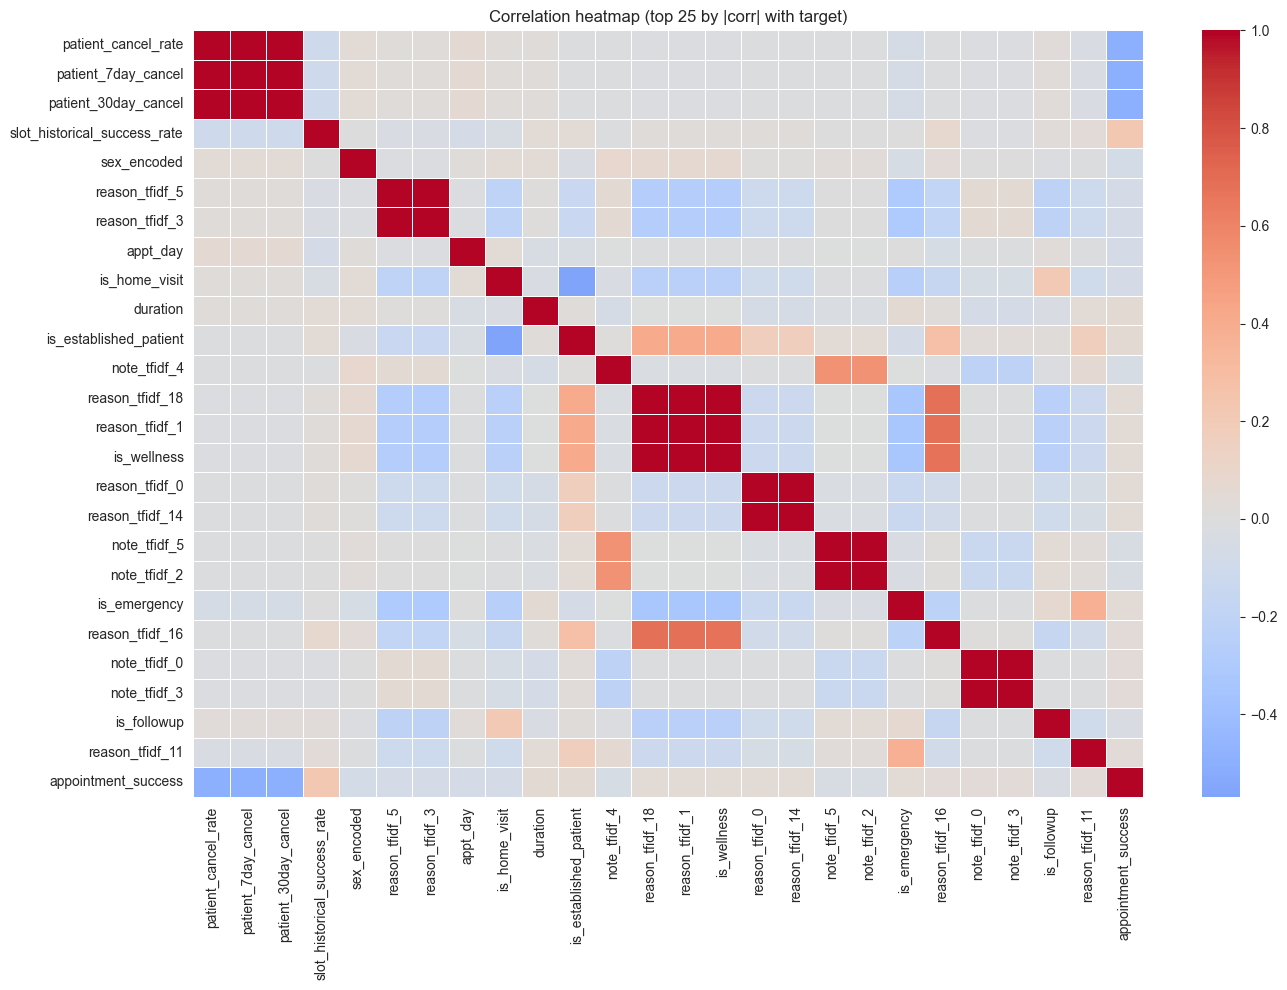

In [ ]:
# Correlation heatmap (top features by absolute correlation with target)
corr = pd.concat([X_all, y_all.rename('appointment_success')], axis=1).corr(numeric_only=True)

# Top absolute correlations with target
corr_target = corr['appointment_success'].drop('appointment_success').sort_values(key=lambda s: s.abs(), ascending=False)
print('Top correlations with appointment_success:')
print(corr_target.head(20).to_string())

top = list(corr_target.head(25).index) + ['appointment_success']
plt.figure(figsize=(14, 10))
sns.heatmap(corr.loc[top, top], cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation heatmap (top 25 by |corr| with target)')
plt.tight_layout()
plt.show()

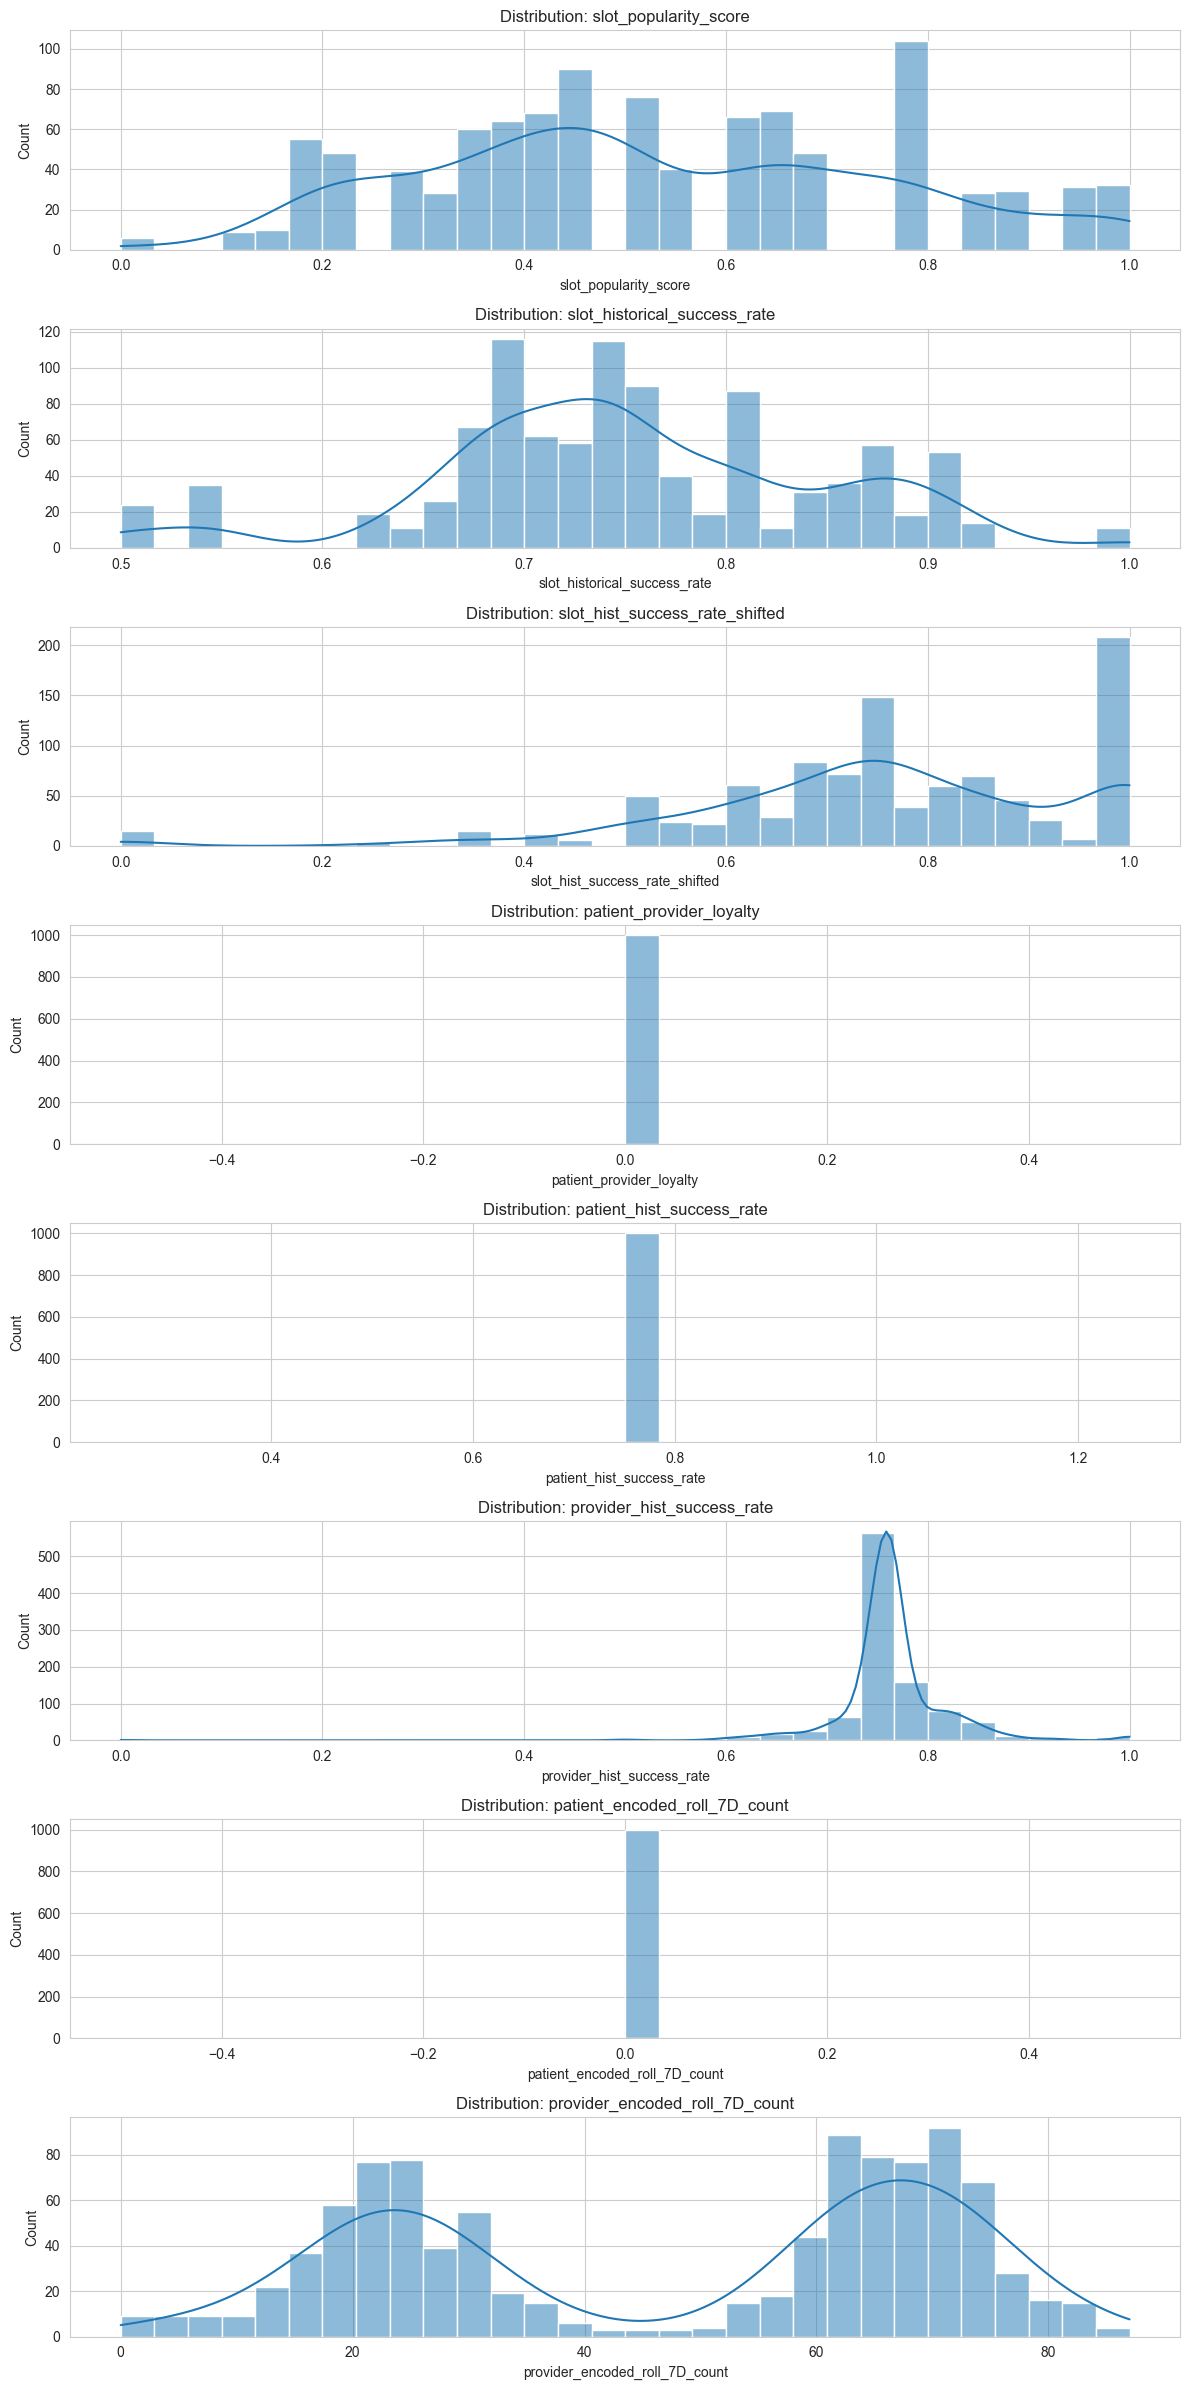

In [ ]:
# Distributions of key engineered features
key_feats = [
    'slot_popularity_score', 'slot_historical_success_rate', 'slot_hist_success_rate_shifted',
    'patient_provider_loyalty', 'patient_hist_success_rate', 'provider_hist_success_rate',
    'patient_encoded_roll_7D_count', 'provider_encoded_roll_7D_count'
]

key_feats = [c for c in key_feats if c in X_all.columns]

fig, axes = plt.subplots(nrows=len(key_feats), ncols=1, figsize=(12, max(3, 3*len(key_feats))))
if len(key_feats) == 1:
    axes = [axes]

for ax, col in zip(axes, key_feats):
    sns.histplot(X_all[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'Distribution: {col}')

plt.tight_layout()
plt.show()

Outlier rate: 0.03


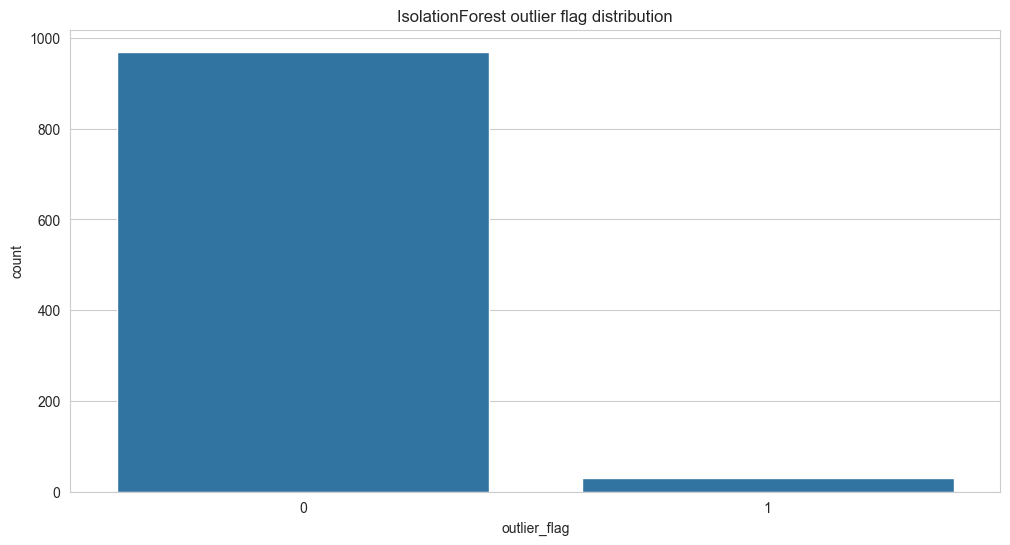

In [ ]:
# Outlier detection (unsupervised) - useful for data quality + robust modeling
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=300, contamination=0.03, random_state=42)
outlier_flag = iso.fit_predict(X_all)

# -1 outlier, +1 inlier
df['outlier_flag'] = (outlier_flag == -1).astype(int)
print('Outlier rate:', df['outlier_flag'].mean().round(4))

sns.countplot(x=df['outlier_flag'])
plt.title('IsolationForest outlier flag distribution')
plt.show()

In [ ]:
# Multicollinearity signals
# 1) High-correlation pairs
corr_X = X_all.corr(numeric_only=True).abs()
upper = corr_X.where(np.triu(np.ones(corr_X.shape), k=1).astype(bool))

high_pairs = (
    upper.stack()
         .sort_values(ascending=False)
         .head(20)
)

print('Top 20 highly-correlated feature pairs (|corr|):')
print(high_pairs.to_string())

# 2) Condition number (large => collinearity)
X_center = X_all - X_all.mean(axis=0)
cond_num = np.linalg.cond(X_center.to_numpy())
print('\nCondition number (centered X):', float(cond_num))

Top 20 highly-correlated feature pairs (|corr|):
has_dual_insurance       secondary_insurance_active    1.0
has_secondary_insurance  secondary_insurance_active    1.0
                         has_dual_insurance            1.0
note_tfidf_2             note_tfidf_5                  1.0
note_tfidf_0             note_tfidf_3                  1.0
appt_month               appt_quarter                  1.0
is_lab                   reason_tfidf_2                1.0
                         reason_tfidf_15               1.0
reason_tfidf_3           reason_tfidf_5                1.0
reason_tfidf_0           reason_tfidf_14               1.0
patient_cancel_rate      patient_30day_cancel          1.0
                         patient_7day_cancel           1.0
reason_tfidf_8           reason_tfidf_9                1.0
reason_tfidf_2           reason_tfidf_12               1.0
                         reason_tfidf_15               1.0
reason_tfidf_12          reason_tfidf_15               1.0
reason_

## 6. Dataset preparation (X, y) + train/test split

We’ll use a **time-based split** on `appt_dt` to better reflect real-world deployment (train on past, test on future).

In [ ]:
# Time-based split
order = df[['appt_dt', '_row_id']].copy()
order['idx'] = np.arange(len(df))
order = order.sort_values(['appt_dt', '_row_id']).reset_index(drop=True)

split_idx = int(len(order) * 0.8)
train_idx = order.loc[:split_idx-1, 'idx'].values
test_idx = order.loc[split_idx:, 'idx'].values

X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
y_train, y_test = y_all.iloc[train_idx], y_all.iloc[test_idx]

print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Train success rate:', y_train.mean().round(4), 'Test success rate:', y_test.mean().round(4))

Train: (800, 105) Test: (200, 105)
Train success rate: 0.7588 Test success rate: 0.72


## 7. Model selection (why each model)

We’ll compare multiple families:
- **Logistic Regression**: strong baseline, fast, interpretable, good for calibrated probabilities with proper regularization.
- **Random Forest**: non-linear, handles interactions, robust to outliers, but can be less calibrated.
- **XGBoost**: high-performing gradient boosting (if available); strong with tabular data.
- **LightGBM**: gradient boosting optimized for speed/accuracy on tabular data (installed in your environment).
- **CatBoost**: strong on categorical-heavy data (often best when raw categoricals are present); will run only if installed.

In production, the typical winners for tabular healthcare ops data are **LightGBM / XGBoost / CatBoost**, with Logistic Regression as a baseline and RandomForest as a sanity-check non-linear model.

In [ ]:
# Model zoo (conditionally enable optional libs)
models = {}

# Logistic Regression: scale numeric features
models['logreg'] = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
])

models['rf'] = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

# LightGBM
try:
    from lightgbm import LGBMClassifier
    models['lgbm'] = LGBMClassifier(
        n_estimators=600,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    )
except Exception as e:
    print('LightGBM not available:', e)

# XGBoost
try:
    from xgboost import XGBClassifier
    models['xgb'] = XGBClassifier(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    )
except Exception as e:
    print('XGBoost not available:', e)

# CatBoost
try:
    from catboost import CatBoostClassifier
    models['cat'] = CatBoostClassifier(
        iterations=800,
        learning_rate=0.05,
        depth=6,
        loss_function='Logloss',
        verbose=False,
        random_seed=42
    )
except Exception as e:
    print('CatBoost not available:', e)

print('Enabled models:', list(models.keys()))

Enabled models: ['logreg', 'rf', 'lgbm', 'xgb', 'cat']


## 8. Baseline training + evaluation (before tuning)

We’ll evaluate with:
- Accuracy
- Precision / Recall / F1
- ROC-AUC (probability quality)

And keep a table for comparison.

In [ ]:
def eval_binary(model, X_te, y_te):
    y_pred = model.predict(X_te)

    # Some models might not expose predict_proba
    y_prob = None
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]

    metrics = {
        'accuracy': accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred, zero_division=0),
        'recall': recall_score(y_te, y_pred, zero_division=0),
        'f1': f1_score(y_te, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_te, y_prob) if y_prob is not None else np.nan
    }
    return metrics, y_pred, y_prob

results = []
trained = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    m, y_pred, y_prob = eval_binary(model, X_test, y_test)
    m['model'] = name
    results.append(m)

results_df = pd.DataFrame(results).set_index('model').sort_values('roc_auc', ascending=False)
results_df

[LightGBM] [Info] Number of positive: 607, number of negative: 193
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005646 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2568
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 84
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.758750 -> initscore=1.145839
[LightGBM] [Info] Start training from score 1.145839
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,accuracy,precision,recall,f1,roc_auc
model,,,,,
logreg,0.635,0.858586,0.590278,0.699588,0.746528
rf,0.830,0.808989,1.000000,0.894410,0.697173
xgb,0.815,0.809249,0.972222,0.883281,0.661954
cat,0.825,0.807910,0.993056,0.890966,0.661086
lgbm,0.810,0.808140,0.965278,0.879747,0.656746


Best baseline: logreg
{'accuracy': 0.635, 'precision': 0.8585858585858586, 'recall': 0.5902777777777778, 'f1': 0.6995884773662552, 'roc_auc': 0.7465277777777777}

Classification report:
              precision    recall  f1-score   support

           0      0.416     0.750     0.535        56
           1      0.859     0.590     0.700       144

    accuracy                          0.635       200
   macro avg      0.637     0.670     0.617       200
weighted avg      0.735     0.635     0.654       200



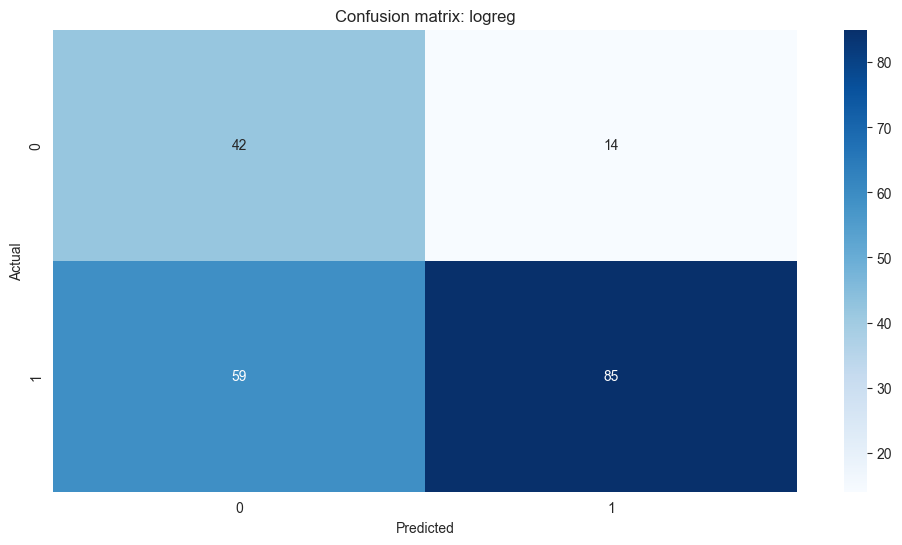

In [ ]:
# Confusion matrix + classification report for the current best baseline
best_name = results_df.index[0]
best_model = trained[best_name]

m, y_pred, y_prob = eval_binary(best_model, X_test, y_test)
print('Best baseline:', best_name)
print(m)

print('\nClassification report:')
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion matrix: {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 9. Hyperparameter tuning (GridSearchCV / RandomizedSearchCV)

We’ll tune a subset of models (most payoff):
- Logistic Regression (regularization strength)
- Random Forest (depth/leaves)
- LightGBM / XGBoost (tree depth, leaves, learning rate, subsample)

To keep runtime reasonable in a notebook, we’ll use:
- **GridSearchCV** for smaller search spaces
- **RandomizedSearchCV** for boosting models

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

searches = {}

# Logistic Regression grid
searches['logreg'] = GridSearchCV(
    estimator=models['logreg'],
    param_grid={
        'clf__C': [0.05, 0.1, 0.2, 0.5, 1.0, 2.0],
        'clf__penalty': ['l2'],
        'clf__solver': ['lbfgs']
    },
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

# Random Forest randomized
searches['rf'] = RandomizedSearchCV(
    estimator=models['rf'],
    param_distributions={
        'n_estimators': [300, 600, 900],
        'max_depth': [None, 6, 10, 16],
        'min_samples_leaf': [1, 2, 4, 8],
        'max_features': ['sqrt', 'log2', 0.5]
    },
    n_iter=15,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=42
)

# LightGBM randomized (if enabled)
if 'lgbm' in models:
    searches['lgbm'] = RandomizedSearchCV(
        estimator=models['lgbm'],
        param_distributions={
            'n_estimators': [300, 600, 1000],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'num_leaves': [15, 31, 63, 127],
            'max_depth': [-1, 4, 6, 10],
            'subsample': [0.7, 0.85, 1.0],
            'colsample_bytree': [0.7, 0.85, 1.0],
            'min_child_samples': [10, 20, 40]
        },
        n_iter=25,
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1,
        random_state=42
    )

# XGBoost randomized (if enabled)
if 'xgb' in models:
    searches['xgb'] = RandomizedSearchCV(
        estimator=models['xgb'],
        param_distributions={
            'n_estimators': [300, 600, 1000],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'max_depth': [3, 5, 7, 9],
            'subsample': [0.7, 0.85, 1.0],
            'colsample_bytree': [0.7, 0.85, 1.0],
            'min_child_weight': [1, 3, 5, 10],
            'reg_lambda': [0.5, 1.0, 2.0]
        },
        n_iter=25,
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1,
        random_state=42
    )

# CatBoost randomized (if enabled)
if 'cat' in models:
    searches['cat'] = RandomizedSearchCV(
        estimator=models['cat'],
        param_distributions={
            'depth': [4, 6, 8, 10],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'iterations': [400, 800, 1200],
            'l2_leaf_reg': [1, 3, 5, 7, 9]
        },
        n_iter=20,
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1,
        random_state=42
    )

print('Searches configured:', list(searches.keys()))

Searches configured: ['logreg', 'rf', 'lgbm', 'xgb', 'cat']


In [ ]:
tuned = {}
tuned_results = []

for name, search in searches.items():
    print('\n' + '='*80)
    print('TUNING:', name)
    print('='*80)
    search.fit(X_train, y_train)
    tuned[name] = search.best_estimator_

    m, y_pred, y_prob = eval_binary(search.best_estimator_, X_test, y_test)
    m['model'] = name
    m['best_params'] = search.best_params_
    tuned_results.append(m)

    print('Best CV ROC-AUC:', round(search.best_score_, 4))
    print('Test ROC-AUC:', round(m['roc_auc'], 4))


tuned_df = pd.DataFrame(tuned_results).set_index('model').sort_values('roc_auc', ascending=False)
tuned_df


TUNING: logreg
Best CV ROC-AUC: 0.7036
Test ROC-AUC: 0.7459

TUNING: rf
Best CV ROC-AUC: 0.7368
Test ROC-AUC: 0.7212

TUNING: lgbm
[LightGBM] [Info] Number of positive: 607, number of negative: 193
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009799 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2568
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 84
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.758750 -> initscore=1.145839
[LightGBM] [Info] Start training from score 1.145839
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

,accuracy,precision,recall,f1,roc_auc,best_params
model,,,,,,
logreg,0.625,0.870968,0.562500,0.683544,0.745908,"{'clf__C': 2.0, 'clf__penalty': 'l2', 'clf__so..."
rf,0.830,0.808989,1.000000,0.894410,0.721230,"{'n_estimators': 300, 'min_samples_leaf': 4, '..."
xgb,0.830,0.812500,0.993056,0.893750,0.686260,"{'subsample': 0.7, 'reg_lambda': 2.0, 'n_estim..."
lgbm,0.825,0.811429,0.986111,0.890282,0.681672,"{'subsample': 0.7, 'num_leaves': 63, 'n_estima..."
cat,0.830,0.808989,1.000000,0.894410,0.659474,"{'learning_rate': 0.03, 'l2_leaf_reg': 3, 'ite..."


## 10. Results visualization

We’ll plot:
- ROC curves
- Precision-Recall curves
- feature importance (for tree models)
- model comparison chart

<Figure size 1200x600 with 0 Axes>

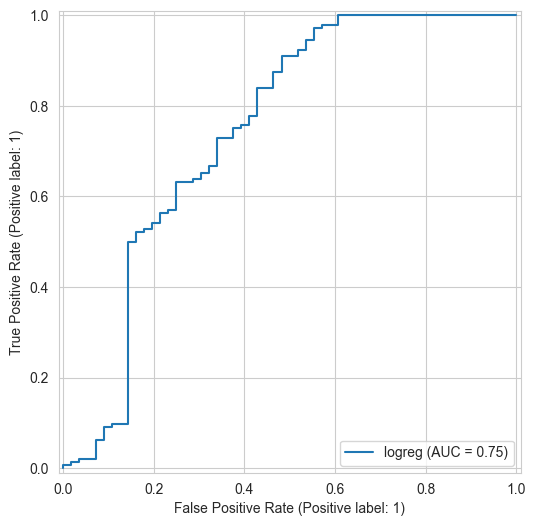

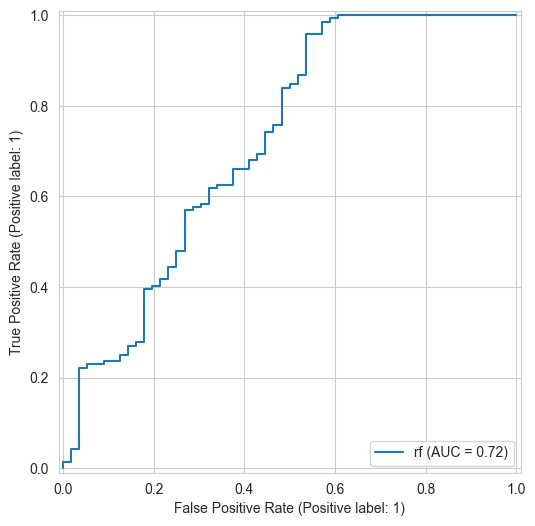

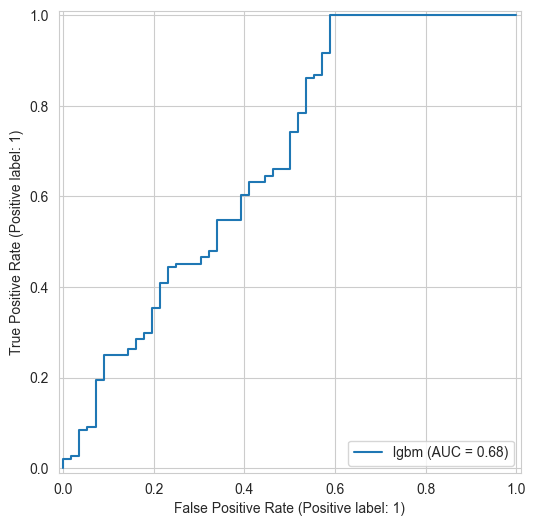

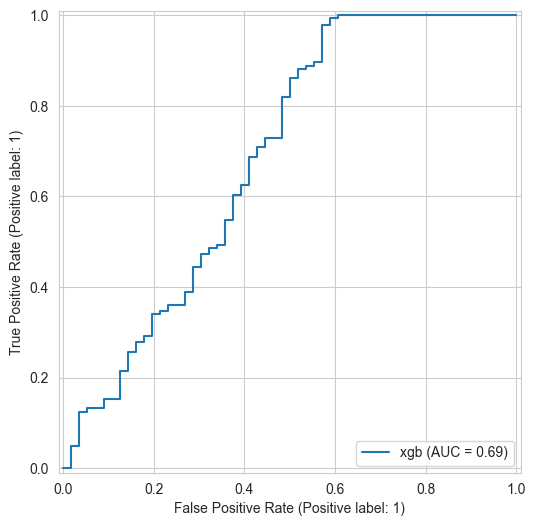

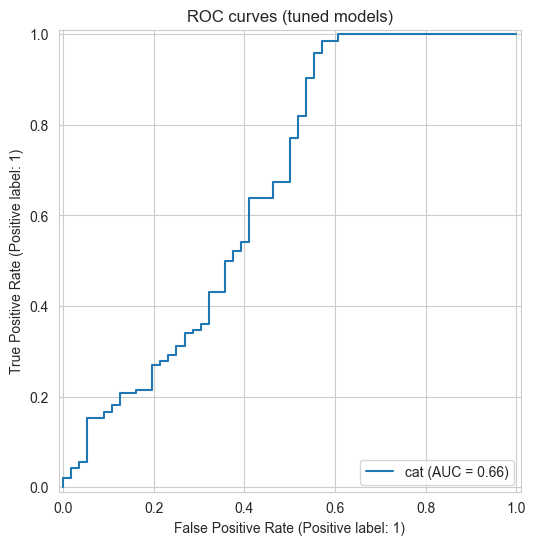

<Figure size 1200x600 with 0 Axes>

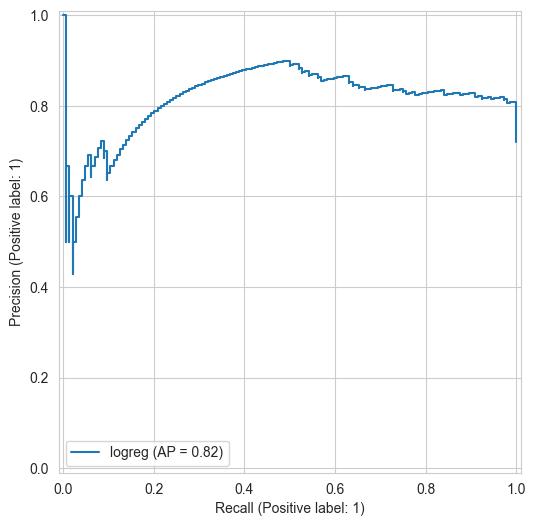

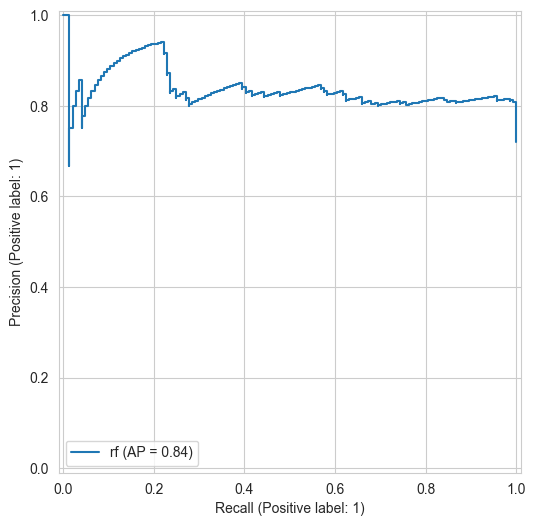

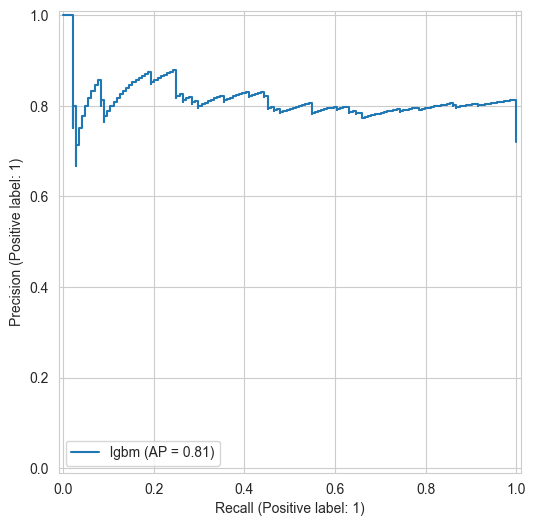

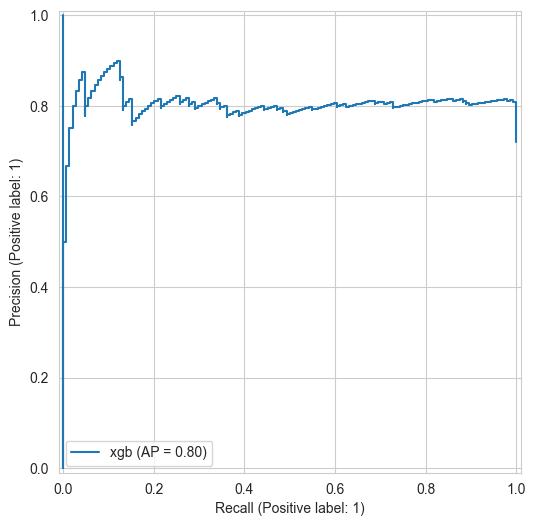

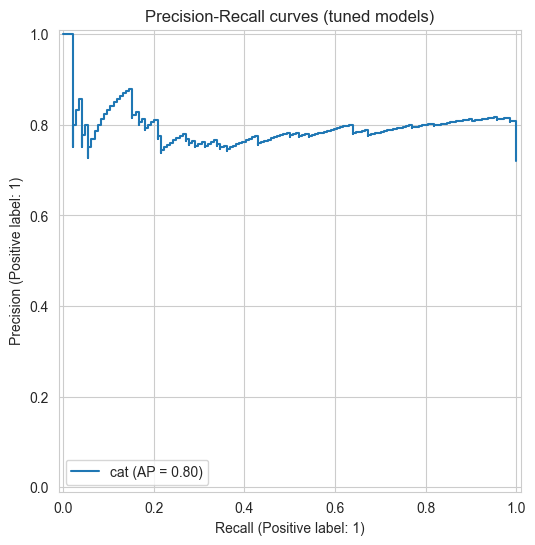

In [ ]:
# ROC + PR curves
plt.figure(figsize=(12, 6))
for name, model in tuned.items():
    if hasattr(model, 'predict_proba'):
        RocCurveDisplay.from_estimator(model, X_test, y_test, name=name)
plt.title('ROC curves (tuned models)')
plt.show()

plt.figure(figsize=(12, 6))
for name, model in tuned.items():
    if hasattr(model, 'predict_proba'):
        PrecisionRecallDisplay.from_estimator(model, X_test, y_test, name=name)
plt.title('Precision-Recall curves (tuned models)')
plt.show()

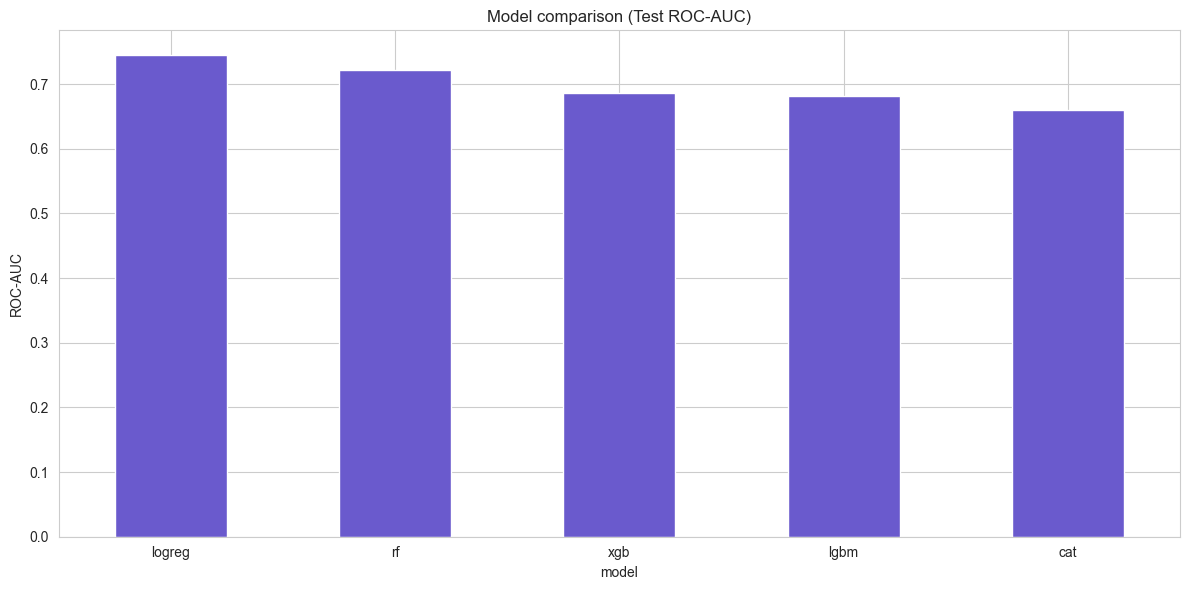

,accuracy,precision,recall,f1,roc_auc
model,,,,,
logreg,0.625,0.870968,0.562500,0.683544,0.745908
rf,0.830,0.808989,1.000000,0.894410,0.721230
xgb,0.830,0.812500,0.993056,0.893750,0.686260
lgbm,0.825,0.811429,0.986111,0.890282,0.681672
cat,0.830,0.808989,1.000000,0.894410,0.659474


In [ ]:
# Model comparison chart
plot_df = tuned_df[['accuracy','precision','recall','f1','roc_auc']].copy()
plot_df = plot_df.sort_values('roc_auc', ascending=False)

ax = plot_df['roc_auc'].plot(kind='bar', color='slateblue')
ax.set_title('Model comparison (Test ROC-AUC)')
ax.set_ylabel('ROC-AUC')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plot_df

Selected best tuned model: logreg

Top 25 important features:
provider_hist_success_rate                1.225131
provider_encoded_roll_30D_success_rate    1.165739
patient_30day_cancel                      0.703131
patient_7day_cancel                       0.703131
patient_cancel_rate                       0.703131
provider_encoded_roll_7D_count            0.686830
slot_historical_success_rate              0.629508
is_home_visit                             0.613502
provider_encoded_roll_30D_count           0.511319
reason_tfidf_4                            0.328574
provider_encoded                          0.318184
appt_day                                  0.297780
reason_tfidf_17                           0.287546
provider_hist_appt_count                  0.269240
provider_total_appts                      0.260074
reason_tfidf_7                            0.250590
is_medicare                               0.249503
provider_30day_util                       0.245373
is_established_patie

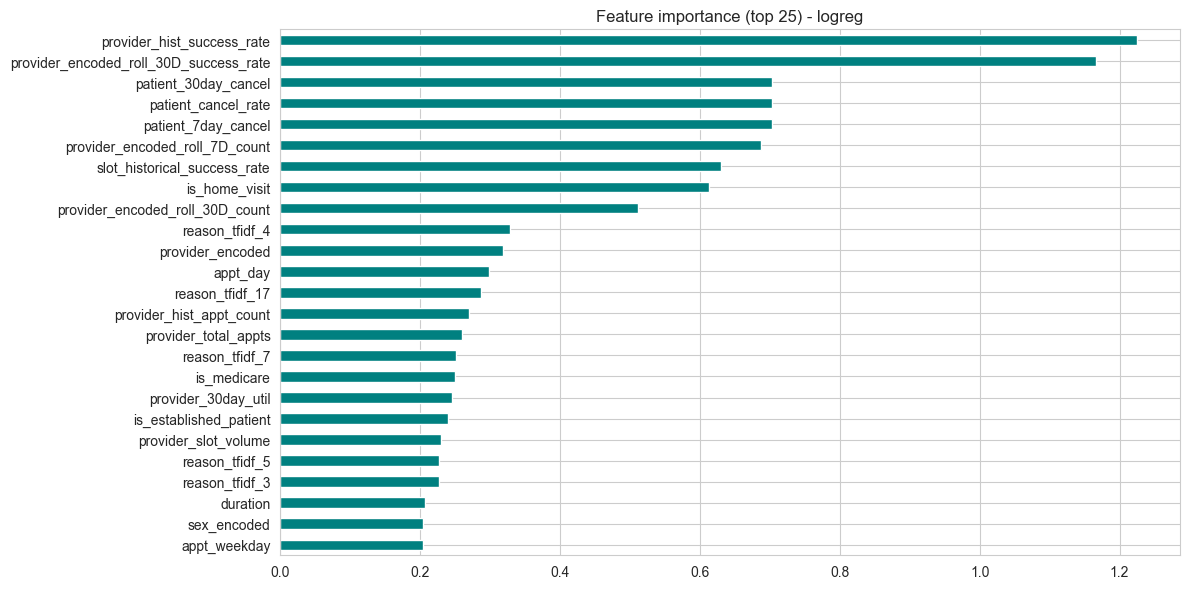

In [ ]:
# Feature importance
best_tuned_name = tuned_df.index[0]
best_tuned_model = tuned[best_tuned_name]
print('Selected best tuned model:', best_tuned_name)

importances = None

# Pipeline case (logreg)
if isinstance(best_tuned_model, Pipeline):
    clf = best_tuned_model.named_steps['clf']
    if hasattr(clf, 'coef_'):
        importances = np.abs(clf.coef_).ravel()

# Tree models
elif hasattr(best_tuned_model, 'feature_importances_'):
    importances = best_tuned_model.feature_importances_

if importances is not None:
    fi = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
    print('\nTop 25 important features:')
    print(fi.head(25).to_string())

    fi.head(25).sort_values().plot(kind='barh', color='teal')
    plt.title(f'Feature importance (top 25) - {best_tuned_name}')
    plt.tight_layout()
    plt.show()
else:
    print('No feature importance available for this model type.')

## 11. Final model selection + persistence

We select the model with the best **test ROC-AUC** (tie-breaker: F1), then save it to `models/slot_prediction_model.pkl`.

In production you would additionally:
- calibrate probabilities (Platt/Isotonic)
- evaluate fairness and subgroup performance
- validate temporal generalization on later months
- log features + predictions for monitoring

In [ ]:
# Pick best tuned model
best_row = tuned_df.sort_values(['roc_auc','f1'], ascending=False).iloc[0]
final_name = best_row.name
final_model = tuned[final_name]

print('Final model:', final_name)
print('Metrics:', tuned_df.loc[final_name, ['accuracy','precision','recall','f1','roc_auc']].to_dict())

model_path = MODELS_DIR / 'slot_prediction_model.pkl'
joblib.dump({
    'model_name': final_name,
    'model': final_model,
    'feature_columns': list(X_train.columns),
    'confirmed_code': confirmed_code,
    'raw_status_classes': list(raw_classes)
}, model_path)

print('Saved model to:', model_path.resolve())

Final model: logreg
Metrics: {'accuracy': 0.625, 'precision': 0.8709677419354839, 'recall': 0.5625, 'f1': 0.6835443037974683, 'roc_auc': 0.7459077380952381}
Saved model to: C:\Users\HP\Desktop\Projects\Appointment Predictor\models\slot_prediction_model.pkl


## 12. What should live in `model_evaluation.ipynb`?

Recommendation:
- Keep **feature creation + feature diagnostics** in `feature_engineering.ipynb`.
- Put **model comparison, tuning, calibration, and final reporting** in `model_evaluation.ipynb`.

Reason: it keeps the pipeline modular (features can iterate without retraining every time) and makes it easier to productionize (feature code becomes the stable contract for training/inference).

That said, because you asked for an end-to-end interview-ready notebook, this notebook includes modeling as well—`model_evaluation.ipynb` can later be used to deepen evaluation (temporal backtesting, subgroup metrics, calibration, confidence intervals).